# Phase 3: Support Team and Priority Prediction

## Objective
Predict the **Support Team** and **Ticket Priority** using semantic embeddings from Sentence-BERT.

## Methodology
1. **Team Consolidation:** Map 10 granular teams into 5 functional departments to improve reliability.
2. **Semantic Features:** Generate 384-dimensional embeddings for ticket descriptions.
3. **Multi-Target Modeling:** Train two independent Logistic Regression classifiers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import json
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sentence_transformers import SentenceTransformer

pd.set_option('display.max_colwidth', 150)
sns.set_style("whitegrid")

print("✅ Environment Setup Complete")

c:\Users\SRINATH\Desktop\data science\machine learing\ml project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Environment Setup Complete


## 1. Load Data and Apply Senior Engineer Mapping

In [ ]:
from pathlib import Path
import pandas as pd

# --- FIXED PATH AND MAPPING ---
data_path = r'c:\Users\dhara\Desktop\An-End-to-End-Semantic-AI-System-for-Automated-Support-Ticket-Handling-main\data\processed\unified_tickets.csv'
df = pd.read_csv(data_path)

print(f"✅ Data loaded: {len(df):,} tickets")

# --- SUPPORT TEAM REFINEMENT ---
# Updating to include all teams from both datasets
team_mapping = {
    'Technical Support': 'Technical Engineering',
    'L2 Support': 'Technical Engineering',
    'IT Support': 'Technical Engineering',
    'Service Outages and Maintenance': 'Technical Engineering',
    
    'Product Support': 'Product & Sales Support',
    'Product Team': 'Product & Sales Support',
    'Sales and Pre-Sales': 'Product & Sales Support',
    
    'Billing and Payments': 'Financial Operations',
    'Billing Team': 'Financial Operations',
    'Returns and Exchanges': 'Financial Operations',
    
    'Human Resources': 'HR / Internal',
    
    'Customer Service': 'General Experience',
    'L1 Support': 'General Experience',
    'General Inquiry': 'General Experience'
}

# Use map and fill any missing ones with a default to avoid NaN
df['refined_team'] = df['support_team'].map(team_mapping).fillna('General Experience')

print("--- Refined Support Teams ---")
print(df['refined_team'].value_counts())

print("\n--- Priority Levels ---")
print(df['priority'].value_counts())

## 2. Feature Preparation and Encoding

In [ ]:
# Encode Teams
le_team = LabelEncoder()
df['team_label'] = le_team.fit_transform(df['refined_team'])
team_names = le_team.classes_

# Encode Priority``
le_priority = LabelEncoder()
df['priority_label'] = le_priority.fit_transform(df['priority'])
priority_names = le_priority.classes_

X_train_text, X_test_text, Y_train, Y_test = train_test_split(
    df['description'], 
    df[['team_label', 'priority_label']], 
    test_size=0.2, 
    random_state=42
)

print(f"📌 TRAINING SET: {len(X_train_text)}")
print(f"📌 TESTING SET: {len(X_test_text)}")

📌 TRAINING SET: 22869
📌 TESTING SET: 5718


In [8]:
df["team_label"]

0        4
1        4
2        0
3        0
4        3
        ..
28582    4
28583    3
28584    2
28585    4
28586    4
Name: team_label, Length: 28587, dtype: int64

In [7]:
# df['priority_label'] = le_priority.fit_transform(df['priority'])
df["priority_label"]

0        0
1        0
2        2
3        1
4        2
        ..
28582    0
28583    0
28584    1
28585    0
28586    1
Name: priority_label, Length: 28587, dtype: int64

## 3. Semantic Embedding Generation (SBERT)

In [4]:
print("🚀 Initializing Sentence-BERT (all-MiniLM-L6-v2)...")
model = SentenceTransformer('all-MiniLM-L6-v2')

print("✨ Generating Train Embeddings (this may take ~45s)...")
X_train_embeddings = model.encode(X_train_text.tolist(), show_progress_bar=True)

print("✨ Generating Test Embeddings...")
X_test_embeddings = model.encode(X_test_text.tolist(), show_progress_bar=True)

print("✅ Feature Engineering Complete")

🚀 Initializing Sentence-BERT (all-MiniLM-L6-v2)...
✨ Generating Train Embeddings (this may take ~45s)...


Batches: 100%|██████████| 715/715 [00:42<00:00, 16.98it/s]


✨ Generating Test Embeddings...


Batches: 100%|██████████| 179/179 [00:10<00:00, 17.28it/s]

✅ Feature Engineering Complete


## 4. Modeling: Support Team Prediction

🏗️ Training Support Team Classifier...
📊 Support Team Performance:
                         precision    recall  f1-score   support

   Financial Operations       0.51      0.52      0.51       911
     General Experience       0.28      0.36      0.32       945
          HR / Internal       0.06      0.41      0.10       117
Product & Sales Support       0.34      0.29      0.31      1190
  Technical Engineering       0.69      0.47      0.56      2555

               accuracy                           0.42      5718
              macro avg       0.38      0.41      0.36      5718
           weighted avg       0.51      0.42      0.45      5718



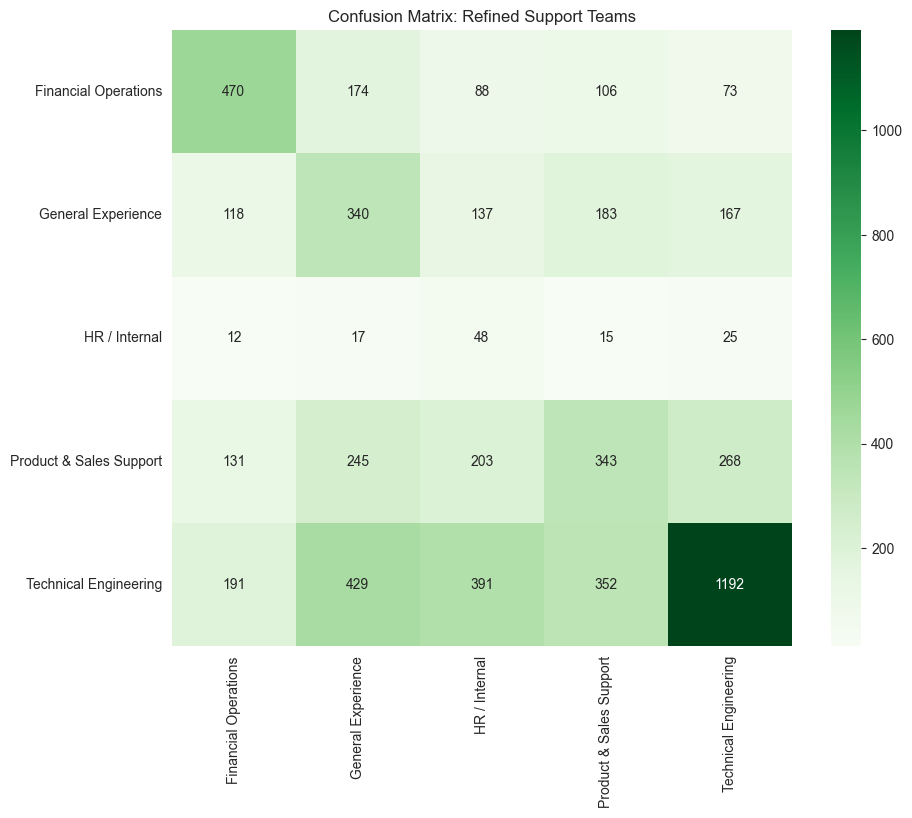

In [9]:
print("🏗️ Training Support Team Classifier...")
team_clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
team_clf.fit(X_train_embeddings, Y_train['team_label'])

y_team_pred = team_clf.predict(X_test_embeddings)

print("📊 Support Team Performance:")
print(classification_report(Y_test['team_label'], y_team_pred, target_names=team_names))

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(Y_test['team_label'], y_team_pred), annot=True, fmt='d', 
            xticklabels=team_names, yticklabels=team_names, cmap='Greens')
plt.title("Confusion Matrix: Refined Support Teams")
plt.show()

## 5. Modeling: Priority Estimation

🏗️ Training Priority Classifier...
📊 Priority Classification Performance:
              precision    recall  f1-score   support

        high       0.55      0.48      0.51      2262
         low       0.30      0.51      0.37      1207
      medium       0.47      0.34      0.39      2249

    accuracy                           0.43      5718
   macro avg       0.44      0.44      0.43      5718
weighted avg       0.46      0.43      0.44      5718



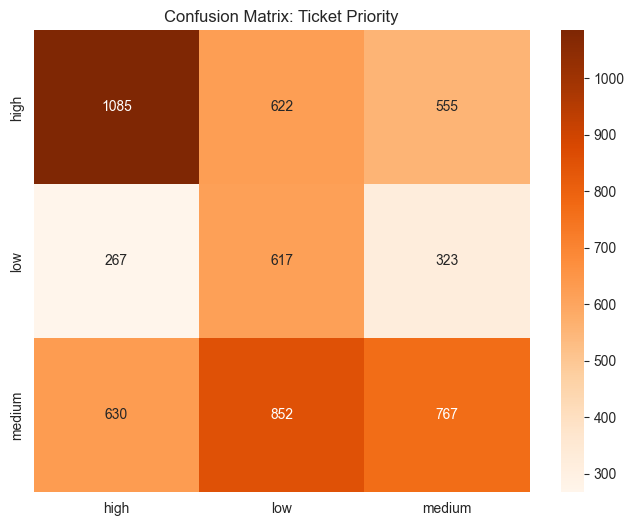

In [10]:
print("🏗️ Training Priority Classifier...")
priority_clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
priority_clf.fit(X_train_embeddings, Y_train['priority_label'])

y_prio_pred = priority_clf.predict(X_test_embeddings)

print("📊 Priority Classification Performance:")
print(classification_report(Y_test['priority_label'], y_prio_pred, target_names=priority_names))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(Y_test['priority_label'], y_prio_pred), annot=True, fmt='d', 
            xticklabels=priority_names, yticklabels=priority_names, cmap='Oranges')
plt.title("Confusion Matrix: Ticket Priority")
plt.show()

## 6. Exporting Phase 3 Models

In [ ]:
export_path = Path('../models/team_priority_classifier')
export_path.mkdir(parents=True, exist_ok=True)

with open(export_path / 'team_classifier.pkl', 'wb') as f:
    pickle.dump(team_clf, f)

with open(export_path / 'priority_classifier.pkl', 'wb') as f:
    pickle.dump(priority_clf, f)

with open(export_path / 'le_team.pkl', 'wb') as f:
    pickle.dump(le_team, f)

with open(export_path / 'le_priority.pkl', 'wb') as f:
    pickle.dump(le_priority, f)

config = {
    "team_mapping": team_mapping,
    "priority_classes": priority_names.tolist(),
    "team_classes": team_names.tolist()
}

with open(export_path / 'config.json', 'w') as f:
    json.dump(config, f, indent=4)

print(f"💾 Phase 3 models successfully exported to: {export_path}")

💾 Phase 3 models successfully exported to: ..\models\team_priority_classifier


: 